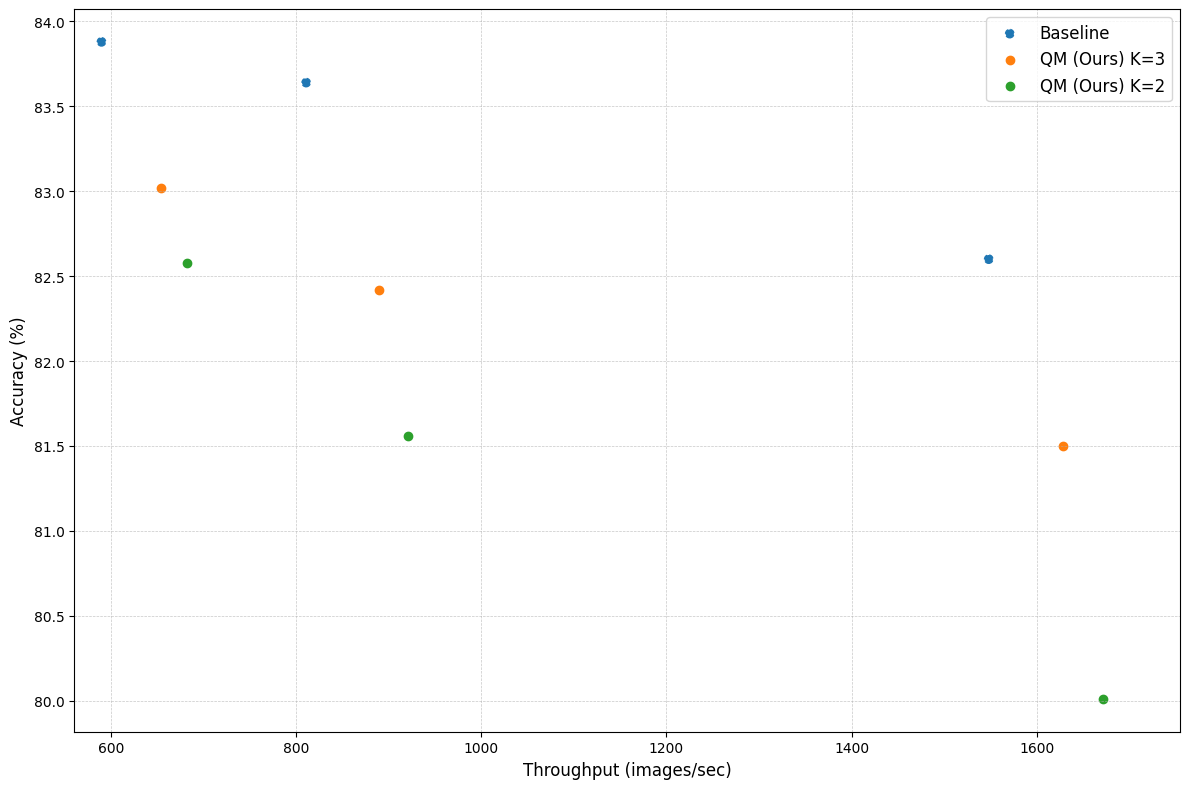

In [15]:
import matplotlib.pyplot as plt

# Data for before/after throughput vs accuracy figure
models = ['VMamba-B', 'VMamba-S', 'VMamba-T']
throughput_before = [590, 811, 1548]  # Baseline throughput
accuracy_before = [83.88, 83.64, 82.6]  # Baseline accuracy
throughput = [654, 890, 1628]  # With QuarterMap throughput
accuracy = [83.02, 82.42, 81.5]  # With QuarterMap accuracy

k2_throughput = [682, 921, 1671]
k2_accuracy = [82.58, 81.56, 80.01]

# Create a larger figure
fig, ax = plt.subplots(figsize=(12, 8))

# Plot before (baseline) and after (QuarterMap)
ax.scatter(throughput_before, accuracy_before, marker='o', linestyle='--', color='tab:blue', label='Baseline')
ax.scatter(throughput, accuracy, marker='o', linestyle='-', color='tab:orange', label='QM (Ours) K=3')
ax.scatter(k2_throughput, k2_accuracy, marker='o', linestyle='-', color='tab:green', label='QM (Ours) K=2')

# Add labels and title
ax.set_xlabel('Throughput (images/sec)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.legend(fontsize=12)

# Set wider axis limits with more padding
x_min = min(throughput_before + throughput + k2_throughput) * 0.95
x_max = max(throughput_before + throughput + k2_throughput) * 1.05
# y_min = min(accuracy_before + accuracy + k2_accuracy) - 1
# y_max = max(accuracy_before + accuracy + k2_accuracy) + 1
ax.set_xlim(x_min, x_max)
# ax.set_ylim(y_min, y_max)

# Annotate points with model types with adjusted positioning
# for i, model in enumerate(models):
#     ax.text(throughput_before[i], accuracy_before[i] - 0.1, model, fontsize=12, ha='center', color='tab:blue')
#     ax.text(throughput[i], accuracy[i] - 0.1, model, fontsize=12, ha='center', color='tab:orange')
#     ax.text(k2_throughput[i], k2_accuracy[i] - 0.1, model, fontsize=12, ha='center', color='tab:green')

# Add grid and adjust layout
plt.grid(visible=True, which="both", linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.savefig('figure_1_throughput_vs_accuracy_1.png', dpi=500, bbox_inches='tight')

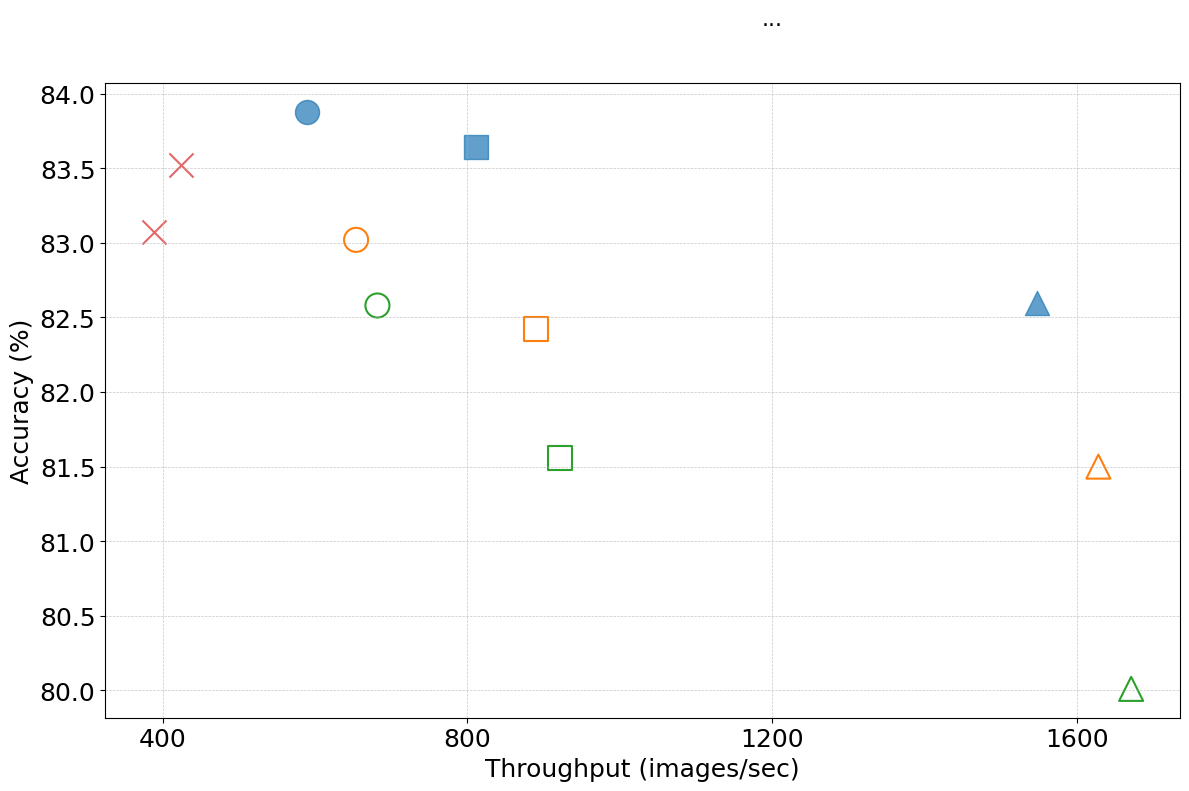

In [1]:
import matplotlib.pyplot as plt

# Data for bubble chart
models = ['VMamba-B', 'VMamba-S', 'VMamba-T']
throughput = [590, 811, 1548]  # Baseline throughput
accuracy = [83.88, 83.64, 82.6]  # Baseline accuracy
speedup = [1.0, 1.0, 1.0]  # Baseline speedup for bubble sizes

throughput_k3 = [654, 890, 1628]  # QM K=3 throughput
accuracy_k3 = [83.02, 82.42, 81.5]  # QM K=3 accuracy
speedup_k3 = [1.11, 1.1, 1.05]  # QM K=3 speedup for bubble sizes

throughput_k2 = [682, 921, 1671]  # QM K=2 throughput
accuracy_k2 = [82.58, 81.56, 80.01]  # QM K=2 accuracy
speedup_k2 = [1.16, 1.14, 1.08]  # QM K=2 speedup for bubble sizes

tome_base_only = [424.28, 388.83]
tome_base_only_accuracy = [83.52, 83.07]

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Marker styles for each model
markers = ['o', 's', '^', 'x']  # Circle for B, square for S, triangle for T

# Plot Baseline with filled markers
for i, model in enumerate(models):
    ax.scatter(
        throughput[i], accuracy[i], 
        s=300, 
        color='tab:blue', 
        alpha=0.7, 
        label='Baseline' if i == 0 else "", 
        marker=markers[i]
    )

# Plot QM K=3 with empty markers
for i, model in enumerate(models):
    ax.scatter(
        throughput_k3[i], accuracy_k3[i], 
        s=300, 
        edgecolor='tab:orange', 
        facecolor='none', 
        linewidth=1.5, 
        label='QM K=3' if i == 0 else "", 
        marker=markers[i]
    )

# Plot QM K=2 with empty markers
for i, model in enumerate(models):
    ax.scatter(
        throughput_k2[i], accuracy_k2[i], 
        s=300, 
        edgecolor='tab:green', 
        facecolor='none', 
        linewidth=1.5, 
        label='QM K=2' if i == 0 else "", 
        marker=markers[i]
    )

# Plot Tome-only
ax.scatter(tome_base_only, tome_base_only_accuracy, s=300, color='tab:red', alpha=0.7, label='ToMe', marker='x')

# Annotate points with model names
# for i, model in enumerate(models):
#     ax.text(throughput[i], accuracy[i] + 0.2, model, fontsize=10, color='tab:blue', ha='center')
#     ax.text(throughput_k3[i], accuracy_k3[i] + 0.2, model, fontsize=10, color='tab:orange', ha='center')
#     ax.text(throughput_k2[i], accuracy_k2[i] + 0.2, model, fontsize=10, color='tab:green', ha='center')

# Add visual break ('...') in the x-axis
ax.text(1200, 84.5, '...', fontsize=16, color='black', ha='center', va='center')

# Narrow the x-axis range

# Compress the blank area between 1000 and 1400
ax.set_xticks([400, 800, 1200, 1600])
ax.set_xticklabels(['400', '800', '1200', '1600'])

# Set axis labels and title
ax.set_xlabel('Throughput (images/sec)', fontsize=18)
ax.set_ylabel('Accuracy (%)', fontsize=18)
ax.tick_params(axis='both', labelsize=18)
# ax.set_title('Throughput vs Accuracy with Speedup', fontsize=14)

# Add grid, legend, and adjust layout
ax.grid(visible=True, linestyle='--', linewidth=0.5, alpha=0.7)

# from matplotlib.lines import Line2D

# custom_markers = [
#     Line2D([0], [0], marker='o', color='tab:blue', label='        Baseline', markersize=10, alpha=0.7, linestyle='None'),
#     Line2D([0], [0], marker='o', color='tab:orange', label='        QM K=3', markersize=10, markerfacecolor='none', linestyle='None', markeredgewidth=1.5),
#     Line2D([0], [0], marker='o', color='tab:green', label='        QM K=2', markersize=10, markerfacecolor='none', linestyle='None', markeredgewidth=1.5)
# ]

# ax.legend(handles=custom_markers, fontsize=12)
plt.tight_layout()

# Show the plot
# plt.show()
plt.savefig('figure_1_throughput_vs_accuracy_3.png', dpi=500)



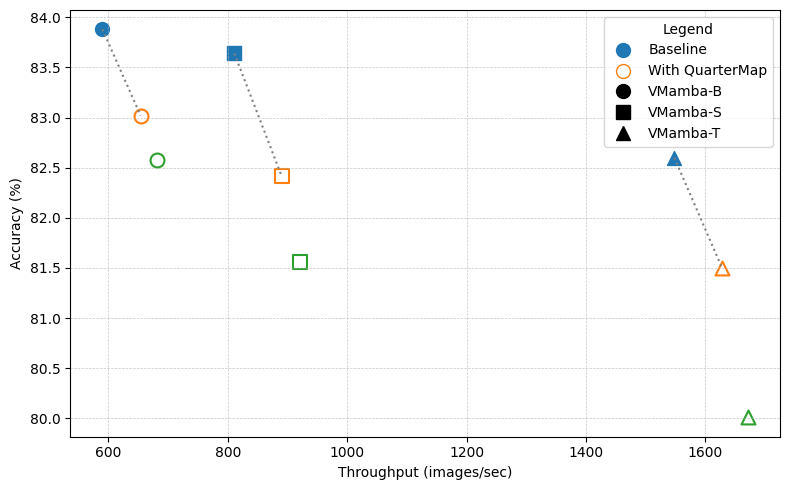

In [9]:
# Streamlined legend for better clarity
fig, ax = plt.subplots(figsize=(8, 5))

# Define shapes for different models
shapes = ['o', 's', '^']  # Circle for B, Square for S, Triangle for T

# Plot before (baseline) with filled markers and different shapes
for i, shape in enumerate(shapes):
    ax.scatter(throughput_before[i], accuracy_before[i], color='tab:blue', s=100, marker=shape)

# Plot after (QuarterMap) with hollow markers and different shapes
for i, shape in enumerate(shapes):
    ax.scatter(throughput[i], accuracy[i], edgecolor='tab:orange', facecolor='white', s=100,
               marker=shape, linewidth=1.5)

# Plot after (QuarterMap) with hollow markers and different shapes
for i, shape in enumerate(shapes):
    ax.scatter(k2_throughput[i], k2_accuracy[i], edgecolor='tab:green', facecolor='white', s=100,
               marker=shape, linewidth=1.5)

# Add labels and title
ax.set_xlabel('Throughput (images/sec)', fontsize=10)
ax.set_ylabel('Accuracy (%)', fontsize=10)

# Custom legend to streamline solid and hollow differences
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='tab:blue', label='Baseline', markersize=10, linestyle='None'),
    plt.Line2D([0], [0], marker='o', color='tab:orange', markerfacecolor='white', label='With QuarterMap', markersize=10, linestyle='None'),
    plt.Line2D([0], [0], marker='o', color='black', label='VMamba-B', markersize=10, linestyle='None'),
    plt.Line2D([0], [0], marker='s', color='black', label='VMamba-S', markersize=10, linestyle='None'),
    plt.Line2D([0], [0], marker='^', color='black', label='VMamba-T', markersize=10, linestyle='None')
]
ax.legend(handles=legend_elements, loc='best', title='Legend', title_fontsize=10)


# Add connecting lines between before and after for each model
for i in range(len(models)):
    ax.plot([throughput_before[i], throughput[i]], [accuracy_before[i], accuracy[i]], linestyle=':', color='gray')

# Add grid and adjust layout
plt.grid(visible=True, which="both", linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.savefig('figure_1_throughput_vs_accuracy_2.png', dpi=500)


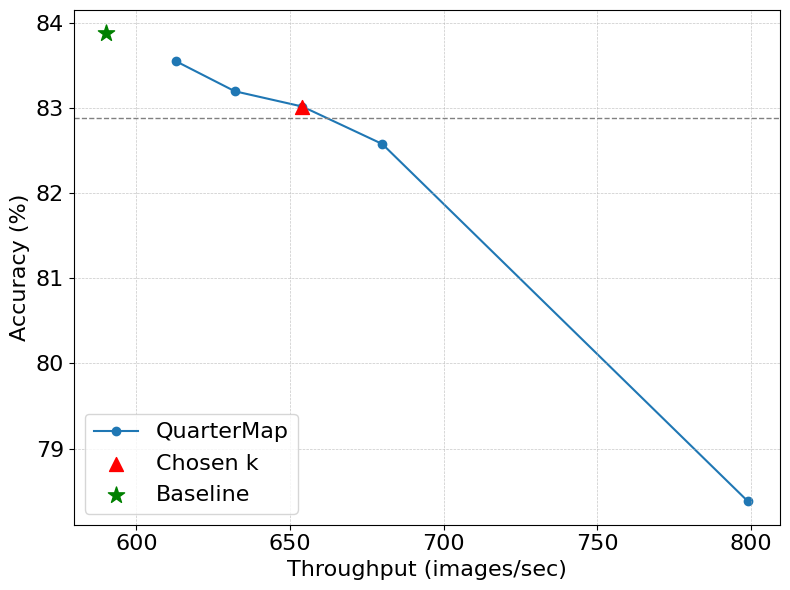

In [4]:
import matplotlib.pyplot as plt

# Raw data
baseline_throughput = 590
baseline_accuracy = 83.88

freqs = [1, 2, 3, 4, 5, 6, 7, 8]
throughput_no_first = [799, 680, 654, 632, 627, 624, 613, 613]
accuracy_no_first = [78.38, 82.58, 83.02, 83.20, 83.52, 83.59, 83.55, 83.74]

show_index = [0, 1, 2, 3, 6]
throughput_no_first = [throughput_no_first[i] for i in show_index]
accuracy_no_first = [accuracy_no_first[i] for i in show_index]
# Highlight the chosen k value
chosen_idx = freqs.index(3)

# Create the plot

# Updated plot with a star for the baseline and a triangle for the chosen point (k = 3)
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the blue line and markers for the "No First Layer" strategy
ax.plot(throughput_no_first, accuracy_no_first, marker='o', linestyle='-', color='tab:blue', label='QuarterMap', zorder=1)

# Highlight the chosen k value (k = 3) with a red triangle
ax.scatter(throughput_no_first[chosen_idx], accuracy_no_first[chosen_idx], color='red', s=100, marker='^', label='Chosen k', zorder=2)

# Plot the baseline point as a green star
ax.scatter(baseline_throughput, baseline_accuracy, color='green', s=150, marker='*', label='Baseline', zorder=2)

baseline_drop_1 = baseline_accuracy - 1  # 1% accuracy drop
ax.axhline(y=baseline_drop_1, color='gray', linestyle='--', linewidth=1)

# Add labels and title
ax.set_xlabel('Throughput (images/sec)', fontsize=16)
ax.set_ylabel('Accuracy (%)', fontsize=16)
ax.tick_params(axis='both', labelsize=16)

# Add grid and legend
ax.legend(fontsize=16)  # Legend to clarify markers
ax.grid(visible=True, which="both", linestyle='--', linewidth=0.5, alpha=0.7)

# Adjust layout and show
plt.tight_layout()
plt.savefig('figure_pareto_optimal_tradeoff.png', dpi=500)
